# S6T3 Data Cleaning Accomodation Nights Booked

Después de ver los métodos de limpieza de datos, preprocesamiento y demás. Ahora se nos pide a través del fichero de `./data/accomodation_nigths_boocked.csv` responder a una serie de preguntas clave que solo son posible si se ha realizado el proceso de limpieza de datos. El dataset contiene las siguientes features:

* `id`: identificador único de cada reserva
* `no_of_adults`: número de adultos
* `no_of_children`: número de niños
* `no_of_weekend_nights`: número de noches de fin de semana (sábado o domingo) que el huésped se alojó o reservó para alojarse en el hotel
* `no_of_week_nights`: número de noches entre semana (de lunes a viernes) que el huésped se alojó o reservó para alojarse en el hotel
* `type_of_meal_plan`: tipo de plan de comidas reservado por el cliente
* `required_car_parking_space`: ¿El cliente requiere un espacio de estacionamiento para el auto? (0 - No, 1 - Sí)
* `room_type_reserved`: tipo de habitación reservada por el cliente. Los valores están cifrados (codificados) por INN Hotels
* `lead_time`: número de días entre la fecha de reserva y la fecha de llegada
* `arrival_year`: año de la fecha de llegada
* `arrival_month`: mes de la fecha de llegada
* `arrival_date`: fecha de llegada
* `market_segment_type`: designación del segmento de mercado
* `repeated_guest`: ¿Es el cliente un huésped repetido? (0 - No, 1 - Sí)
* `no_of_previous_cancellations`: número de reservas anteriores que fueron canceladas por el cliente antes de la reserva actual
* `no_of_previous_bookings_not_canceled`: número de reservas anteriores no canceladas por el cliente antes de la reserva actual
* `avg_price_per_room`: precio promedio por día de la reserva; los precios de las habitaciones son dinámicos (en euros)
* `no_of_special_requests`: número total de solicitudes especiales realizadas por el cliente (por ejemplo, piso alto, vista desde la habitación, etc.)
booking_status (0 o 1)

Las preguntas clave a responder son:

1. ¿En qué trimestre se producen un menor número de cancelaciones para las reservas de hotel tipo ciudad?
2. ¿Qué relación existe entre la variable lead_time y las cancelaciones de las reservas?
3. ¿Qué relación existe entre la variable deposit_type y la cancelación de la reserva?
4. ¿Qué mes del año tiene un precio medio de reserva mayor para las reservas de hotel tipo resort?

## Import Libraries and Load Data

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [3]:
# Load data
df = pd.read_csv('../data/accomodation_nights_booked.csv')
df.sample(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
7489,Resort Hotel,1,13,2016,August,33,12,0,2,2,0.0,0,HB,ESP,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,240.0,NaN,0,Transient,291.00,0,0,Canceled,2016-07-31
37555,Resort Hotel,0,105,2017,June,24,15,2,5,2,1.0,0,HB,FRA,Direct,Direct,0,0,0,H,H,1,No Deposit,250.0,NaN,0,Transient,230.00,0,0,Check-Out,2017-06-22
14868,Resort Hotel,1,289,2015,November,48,26,0,1,2,0.0,0,BB,PRT,Online TA,TA/TO,0,1,0,A,A,0,No Deposit,240.0,NaN,0,Transient,36.00,0,0,Canceled,2015-03-06
28883,Resort Hotel,0,235,2016,October,43,17,1,1,2,0.0,0,BB,BEL,Direct,Direct,0,0,1,D,D,0,No Deposit,NaN,NaN,0,Transient,68.50,0,1,Check-Out,2016-10-19
24389,Resort Hotel,0,0,2016,May,21,19,0,0,2,0.0,0,BB,CN,Online TA,TA/TO,1,0,0,A,I,0,No Deposit,240.0,NaN,0,Transient,0.00,0,0,Check-Out,2016-05-19
22362,Resort Hotel,0,20,2016,March,13,20,2,2,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,60.00,0,1,Check-Out,2016-03-24
92715,City Hotel,0,176,2016,July,28,8,1,2,2,0.0,0,BB,BEL,Direct,Direct,0,0,0,A,A,0,No Deposit,14.0,NaN,0,Transient-Party,85.50,0,0,Check-Out,2016-07-11
39895,Resort Hotel,0,10,2017,August,35,31,0,2,2,0.0,0,BB,NLD,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,175.00,0,2,Check-Out,2017-09-02
47976,City Hotel,1,17,2016,March,11,11,1,2,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,97.00,0,0,Canceled,2016-02-25
96722,City Hotel,0,204,2016,September,36,3,2,2,2,0.0,0,BB,NLD,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,121.0,NaN,0,Transient-Party,80.75,0,2,Check-Out,2016-09-07


## Data Cleaning

Veamos ahora como esta puesta la data y que valores nulos y el estado de la data en tipos.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

Por lo que vemos, los valores nulos estan presentes en `childre`, `country`, `agent` y `company`. Para responder las preguntas, incialmente no parece ser necesario tratarlos.

Para responder a la primera pregunta, debemos procesar para encontrar el numero de trimestres mediante la columna de `reservation_status_date`. Por tanto, vamos a crear una nueva columna al respecto.

In [5]:
# Get quarter number throught `reservation_satus_date``
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['reservation_status_quarter'] = 'Q' + df.reservation_status_date.dt.quarter.astype(str)

Para responder la segunda pregunta, vamos a crear una nueva columna que indique si la reserva fue cancelada o no. Para ello, vamos a usar la columna `reservation_status` y asignar un valor de 1 para las reservas canceladas y 0 para las reservas no canceladas.

In [6]:
# Boolean column for cancelled reservations
df['is_cancelled'] = df['reservation_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

Para la tercera pregunta no necesitamos transformaciones adicionales, ya que la columna `deposit_type` ya está en un formato adecuado para su análisis. No es necesario una recodificación adicional, ya que los valores categóricos de `deposit_type` no tienen ranking que entrege información adicional.

Para la cuarta y última pregunta, no es necesario realizar transformaciones adicionales, ya que las columnas `arraival_date_month` y `avg_price_per_room` ya están en un formato adecuado para su análisis. No posee valores nulos y podemos trabajarlos tal y como se encuentran.

## a. ¿En qué trimestre se producen un menor número de cancelaciones para las reservas de hotel tipo ciudad?

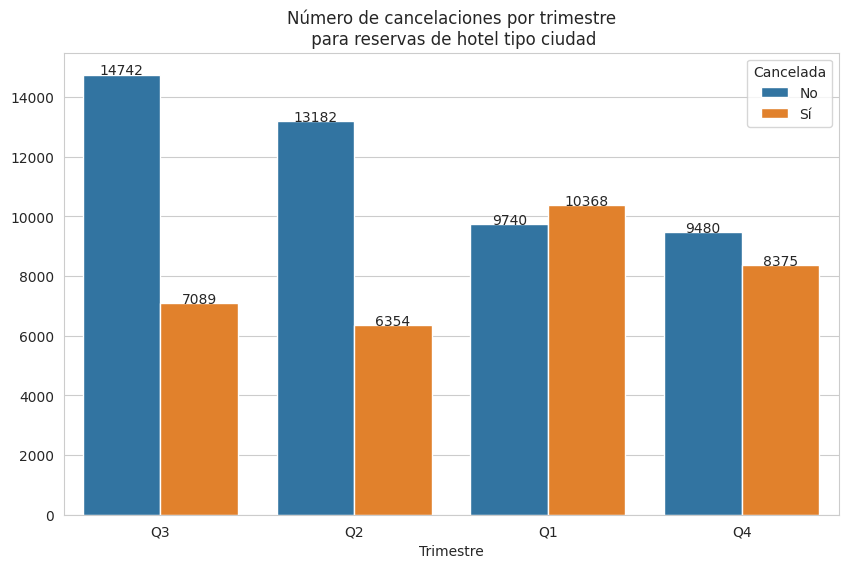

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df[df.hotel == "City Hotel"], 
    x='reservation_status_quarter', hue='is_cancelled')

# Labels over bars
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.text(p.get_x() + p.get_width() / 2., height + 5, int(height), ha='center')

plt.title('Número de cancelaciones por trimestre\n para reservas de hotel tipo ciudad')
plt.xlabel('Trimestre')
plt.ylabel('')
plt.legend(title='Cancelada', labels=['No', 'Sí'])
plt.show()

Parece ser que la cantidad de reservas canceladas se concentran en el primer trimestre del año, siendo superior a la cantidad de reservas no canceladas. A este le sigue el cuarto trimestre. Parece existir mayor cantidad de cancelaciones en reservas de hotel tipo ciudad, sobre todo en esas épocas del año asociadas a temporadas navideñas y de invierno.

## b.¿Qué relación existe entre la variable `lead_time` y las cancelaciones de las reservas?

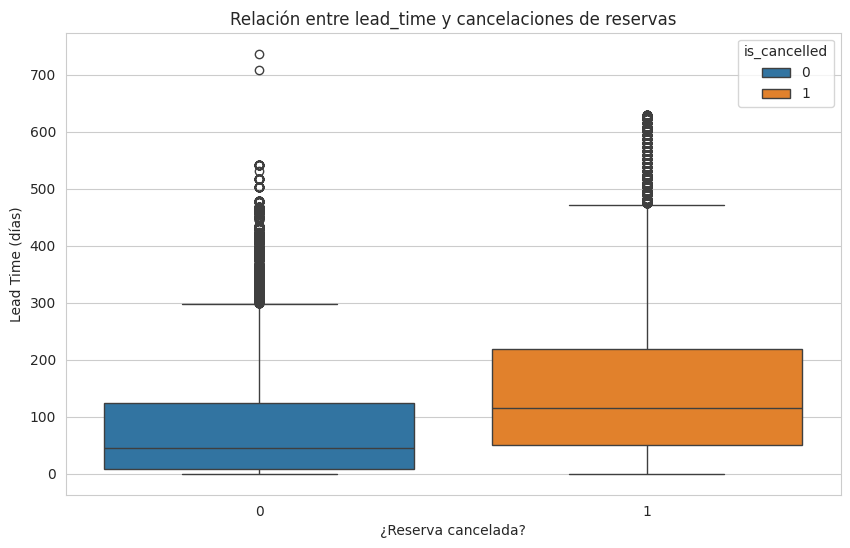

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x='is_cancelled', y='lead_time', ax=ax, hue='is_cancelled', dodge=False)
ax.set_title('Relación entre lead_time y cancelaciones de reservas')
ax.set_xlabel('¿Reserva cancelada?')
ax.set_ylabel('Lead Time (días)')

plt.show()

Parece existir una relación entre la variable `lead_time` y las cancelaciones de las reservas. En general, las reservas que fueron canceladas tienden a tener un `lead_time` mas alto, lo que puede hacer referencia a que son realizadas con mayor anticipación y que finalmente no se concreta.

## c.¿Qué relación existe entre la variable `deposit_type` y la cancelación de la reserva?

In [15]:
from scipy.stats import chi2_contingency

data_chi2 = pd.crosstab(df['deposit_type'], df['is_cancelled'])
print(data_chi2)

chi2, p, dof, expected = chi2_contingency(data_chi2)
print(f"\nχ²: {chi2}, p-value: {p}")

is_cancelled      0      1
deposit_type              
No Deposit    76119  28522
Non Refund      127  14460
Refundable      127     35

χ²: 28707.209427053283, p-value: 0.0


Hagamos Cramer's V para medir la asociación entre `deposit_type` y `is_cancelled`.

In [16]:
n = data_chi2.sum().sum()
min_dim = min(data_chi2.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Cramér's V: {cramers_v}")

Cramér's V: 0.49035602146128754


Realizadno un Chi2 de contigencia, tenemos aun p-value aproximadamente de 0.0, sin lugar a dudas rechaza la hipótesis nula $h_o$ de independencia entre las variables `deposit_type` y `is_cancelled`. Cramer's V de aproximadamente 0.49 nos confirma la fuerza y dirección de la asociación entre ambas vairbales. Por tanto, podemos concluir que existe una relación significativa entre el tipo de depósito y la cancelación de la reserva. Es decir, el tipo de depósito que se realiza en una reserva tiene un impacto significativo en la probabilidad de que esa reserva sea cancelada o no.

In [21]:
print(pd.crosstab(df['deposit_type'], df['is_cancelled'], normalize='index').round(2) * 100)

is_cancelled     0     1
deposit_type            
No Deposit    73.0  27.0
Non Refund     1.0  99.0
Refundable    78.0  22.0


## d. ¿Qué mes del año tiene un precio medio de reserva mayor para las reservas de hotel tipo resort?

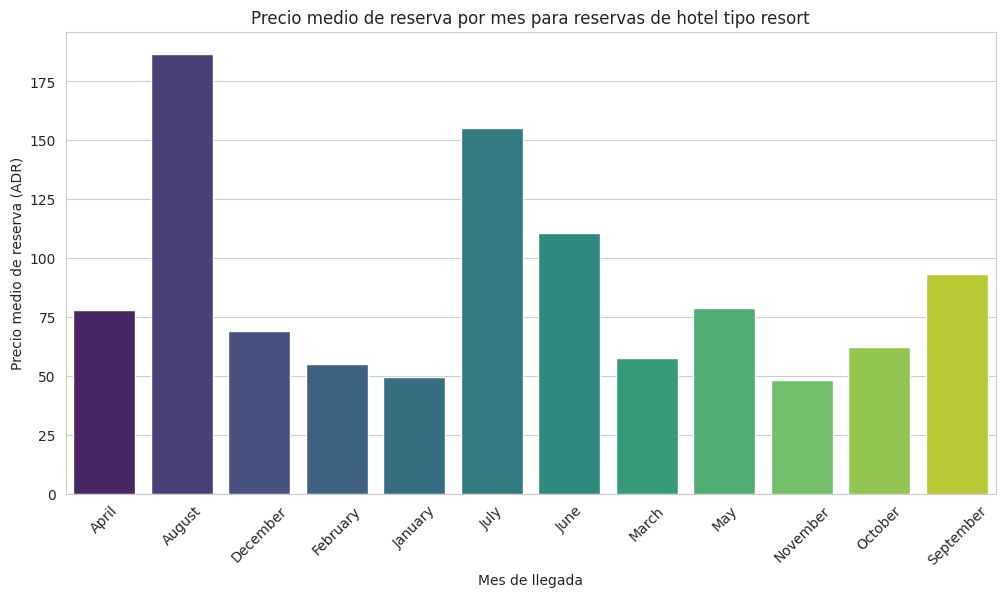

In [28]:
price_mean = df[df.hotel == 'Resort Hotel'].groupby('arrival_date_month')['adr'].mean().reset_index().round(2)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=price_mean, x='arrival_date_month', y='adr', ax=ax, palette='viridis', hue ='arrival_date_month', dodge=False)
ax.set_title('Precio medio de reserva por mes para reservas de hotel tipo resort')
ax.set_xlabel('Mes de llegada')
ax.set_ylabel('Precio medio de reserva (ADR)')
plt.xticks(rotation=45)
plt.show()

La alta temorada de verano es propia para los resorts, y podemos comprobar que el precio medio suele ser mas alto en los meses de agosto, juliuo y junio, siendo agosto el mes con el precio medio de reserva mas alto para las reservas de hotel tipo resort. Esto se debe a que durante estos meses, la demanda de alojamiento en resorts suele ser mayor debido a las vacaciones escolares y al clima favorable para actividades al aire libre, lo que puede llevar a un aumento en los precios de las habitaciones.